<a href="https://colab.research.google.com/github/Dulandi-Dinethya/SE4050-Deep_Learning_Assignment/blob/IT23211278/SE4050_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
data_root = '/kaggle/input/palm-dataset'

import os
for root, dirs, files in os.walk(data_root):
    level = root.replace(data_root, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/  -> {len(files)} files, {len(dirs)} subfolders')
    if level < 2:
        for f in files[:3]:
            print(f'{indent}  e.g. {f}')

In [29]:
import os
from google.colab import userdata
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')

In [30]:
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [31]:
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("saqibshoaibdz/palm-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'palm-dataset' dataset.
Path to dataset files: /kaggle/input/palm-dataset


In [32]:
data_root = path  # = /root/.cache/kagglehub/datasets/saqibshoaibdz/palm-dataset/versions/1
sessions = ['session1', 'session2']

import cv2, numpy as np, math, os, csv
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

!ls {data_root}

session1  session2


In [33]:
img_path = f'{path}/session1/01095.tiff'
img = Image.open(img_path)
print("Size:", img.size, "| Mode:", img.mode)

Size: (800, 600) | Mode: RGB


In [34]:
!ls {path}
!ls {path}/session1 | head -5!ls {path}
!ls {path}/session1 | head -5

session1  session2
head: invalid trailing option -- !
Try 'head --help' for more information.
00001.tiff
00002.tiff
00003.tiff
00004.tiff
00005.tiff


Size: (800, 600) | Mode: RGB


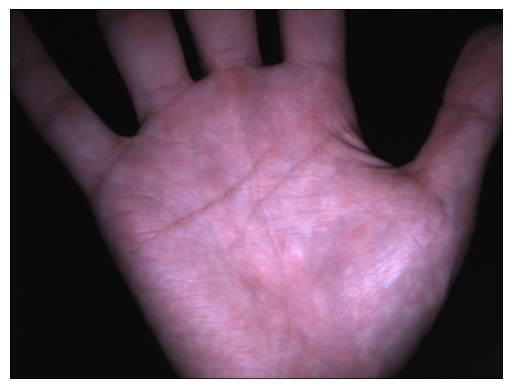

In [35]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = '/kaggle/input/palm-dataset/session1/01095.tiff'
img = Image.open(img_path)
print("Size:", img.size, "| Mode:", img.mode)

plt.imshow(img, cmap='gray' if img.mode == 'L' else None)
plt.axis('off')
plt.show()

In [36]:
import os
files = sorted(os.listdir('/kaggle/input/palm-dataset/session1'))
print(files[:10])
print(files[-10:])
print(len(files))

['00001.tiff', '00002.tiff', '00003.tiff', '00004.tiff', '00005.tiff', '00006.tiff', '00007.tiff', '00008.tiff', '00009.tiff', '00010.tiff']
['05991.tiff', '05992.tiff', '05993.tiff', '05994.tiff', '05995.tiff', '05996.tiff', '05997.tiff', '05998.tiff', '05999.tiff', '06000.tiff']
6000


In [37]:
!find /kaggle/input/palm-dataset -maxdepth 1 -type f

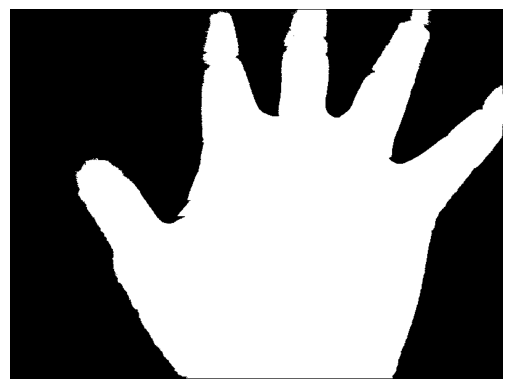

In [38]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/kaggle/input/palm-dataset/session1/00001.tiff')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.axis('off')
plt.show()

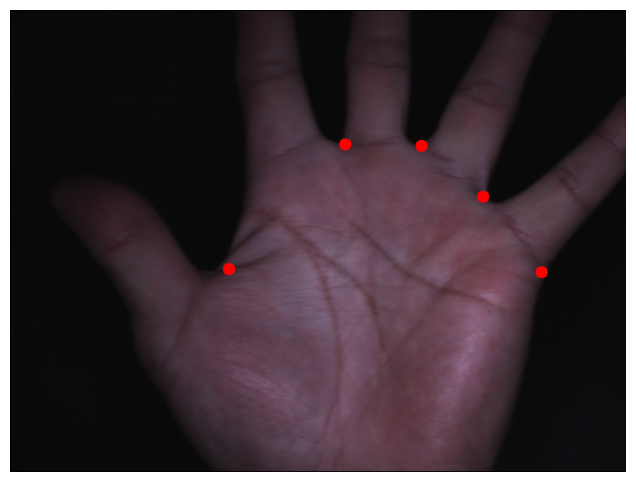

Found 5 valley candidates
(np.int32(614), np.int32(242)) depth=214.8
(np.int32(284), np.int32(336)) depth=181.1
(np.int32(534), np.int32(176)) depth=175.0
(np.int32(435), np.int32(174)) depth=172.5
(np.int32(690), np.int32(340)) depth=43.1


In [39]:
import numpy as np

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
hand_contour = max(contours, key=cv2.contourArea)

hull = cv2.convexHull(hand_contour, returnPoints=False)
hull = np.sort(hull, axis=0)  # OpenCV requires hull indices in increasing order
defects = cv2.convexityDefects(hand_contour, hull)
defects = defects.reshape(-1, 4)

vis = img.copy()
valley_points = []

for i in range(defects.shape[0]):
    s, e, f, d = defects[i]
    far = tuple(hand_contour[f][0])
    depth = d / 256.0
    if depth > 20:
        valley_points.append((far, depth))
        cv2.circle(vis, far, 8, (0, 0, 255), -1)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

print(f"Found {len(valley_points)} valley candidates")
for pt, d in sorted(valley_points, key=lambda x: -x[1]):
    print(pt, f"depth={d:.1f}")

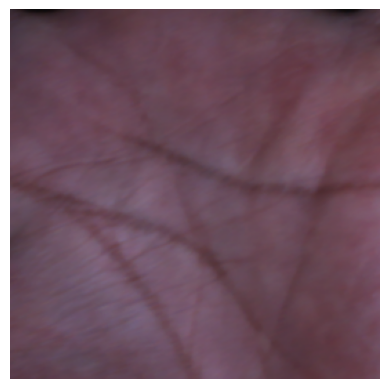

ROI shape: (268, 268, 3)


In [40]:
import math

p1 = np.array([435, 174])  # index-middle valley
p2 = np.array([614, 242])  # ring-pinky valley

# midpoint and distance between the two valley points
midpoint = (p1 + p2) / 2
dist = np.linalg.norm(p2 - p1)

# angle of the line between them, so we can rotate the hand upright
angle = math.degrees(math.atan2(p2[1] - p1[1], p2[0] - p1[0]))

# rotate the whole image so the p1-p2 line becomes horizontal
h, w = img.shape[:2]
rot_matrix = cv2.getRotationMatrix2D(tuple(midpoint), angle, 1.0)
rotated = cv2.warpAffine(img, rot_matrix, (w, h))

# recompute p1, p2 position after rotation (they now lie on a horizontal line at midpoint's y)
# ROI square: side length = distance between valley points (scaled slightly), positioned BELOW the line (toward palm)
side = int(dist * 1.4)
roi_x1 = int(midpoint[0] - side / 2)
roi_y1 = int(midpoint[1])  # start just below the valley line
roi_x2 = roi_x1 + side
roi_y2 = roi_y1 + side

roi = rotated[roi_y1:roi_y2, roi_x1:roi_x2]

plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
print("ROI shape:", roi.shape)

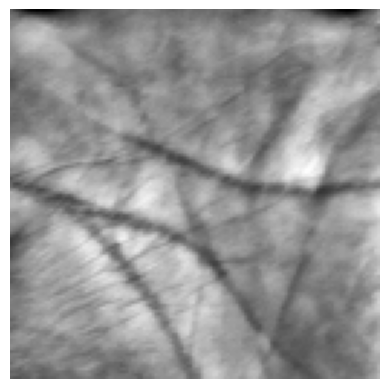

In [41]:
roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(roi_gray)
resized = cv2.resize(enhanced, (128, 128))

plt.imshow(resized, cmap='gray')
plt.axis('off')
plt.show()

In [42]:
def preprocess_palm(img_path, output_size=128, min_depth=100):
    img = cv2.imread(img_path)
    if img is None:
        return None, "unreadable"

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None, "no_contour"
    hand_contour = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(hand_contour, returnPoints=False)
    hull = np.sort(hull, axis=0)
    defects = cv2.convexityDefects(hand_contour, hull)
    if defects is None:
        return None, "no_defects"
    defects = defects.reshape(-1, 4)

    valley_points = []
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i]
        far = tuple(hand_contour[f][0])
        depth = d / 256.0
        if depth > min_depth:
            valley_points.append((far, depth))

    if len(valley_points) < 2:
        return None, "insufficient_valleys"

    # take the two highest-depth points EXCLUDING likely wrist/edge noise
    # (sort by depth, then by x-position to get a left-right pair across the palm)
    valley_points = sorted(valley_points, key=lambda x: -x[1])[:4]
    valley_points = sorted(valley_points, key=lambda x: x[0][0])  # left to right
    p1 = np.array(valley_points[0][0])
    p2 = np.array(valley_points[-1][0])

    midpoint = (p1 + p2) / 2
    dist = np.linalg.norm(p2 - p1)
    angle = math.degrees(math.atan2(p2[1] - p1[1], p2[0] - p1[0]))

    h, w = img.shape[:2]
    rot_matrix = cv2.getRotationMatrix2D(tuple(midpoint), angle, 1.0)
    rotated = cv2.warpAffine(img, rot_matrix, (w, h))

    side = int(dist * 1.4)
    roi_x1 = int(midpoint[0] - side / 2)
    roi_y1 = int(midpoint[1])
    roi_x2 = roi_x1 + side
    roi_y2 = roi_y1 + side

    if roi_x1 < 0 or roi_y1 < 0 or roi_x2 > w or roi_y2 > h:
        return None, "roi_out_of_bounds"

    roi = rotated[roi_y1:roi_y2, roi_x1:roi_x2]
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(roi_gray)
    resized = cv2.resize(enhanced, (output_size, output_size))

    return resized, "ok"

In [43]:
import os
test_files = sorted(os.listdir('/kaggle/input/palm-dataset/session1'))[:10]
for f in test_files:
    path = f'/kaggle/input/palm-dataset/session1/{f}'
    result, status = preprocess_palm(path)
    print(f, status)

00001.tiff roi_out_of_bounds
00002.tiff roi_out_of_bounds
00003.tiff roi_out_of_bounds
00004.tiff roi_out_of_bounds
00005.tiff roi_out_of_bounds
00006.tiff roi_out_of_bounds
00007.tiff roi_out_of_bounds
00008.tiff roi_out_of_bounds
00009.tiff roi_out_of_bounds
00010.tiff roi_out_of_bounds


In [44]:
def preprocess_palm(img_path, output_size=128, min_depth=100):
    img = cv2.imread(img_path)
    if img is None:
        return None, "unreadable"

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None, "no_contour"
    hand_contour = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(hand_contour, returnPoints=False)
    hull = np.sort(hull, axis=0)
    defects = cv2.convexityDefects(hand_contour, hull)
    if defects is None:
        return None, "no_defects"
    defects = defects.reshape(-1, 4)

    valley_points = []
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i]
        far = tuple(hand_contour[f][0])
        depth = d / 256.0
        if depth > min_depth:
            valley_points.append((far, depth))

    if len(valley_points) < 3:
        return None, "insufficient_valleys"

    # sort left-to-right by x position
    valley_points = sorted(valley_points, key=lambda x: x[0][0])

    # skip the thumb-index valley (leftmost) — use 2nd-from-left and rightmost
    # (index-middle valley and ring-pinky valley)
    p1 = np.array(valley_points[1][0])
    p2 = np.array(valley_points[-1][0])

    midpoint = (p1 + p2) / 2
    dist = np.linalg.norm(p2 - p1)
    angle = math.degrees(math.atan2(p2[1] - p1[1], p2[0] - p1[0]))

    h, w = img.shape[:2]
    rot_matrix = cv2.getRotationMatrix2D(tuple(midpoint), angle, 1.0)
    rotated = cv2.warpAffine(img, rot_matrix, (w, h))

    side = int(dist * 1.2)  # reduced from 1.4 — tighter, safer margin
    roi_x1 = int(midpoint[0] - side / 2)
    roi_y1 = int(midpoint[1])
    roi_x2 = roi_x1 + side
    roi_y2 = roi_y1 + side

    # clamp to image bounds instead of rejecting outright
    roi_x1, roi_y1 = max(0, roi_x1), max(0, roi_y1)
    roi_x2, roi_y2 = min(w, roi_x2), min(h, roi_y2)

    if roi_x2 - roi_x1 < 50 or roi_y2 - roi_y1 < 50:
        return None, "roi_too_small"

    roi = rotated[roi_y1:roi_y2, roi_x1:roi_x2]
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(roi_gray)
    resized = cv2.resize(enhanced, (output_size, output_size))

    return resized, "ok"

In [45]:
test_files = sorted(os.listdir('/kaggle/input/palm-dataset/session1'))[:10]
for f in test_files:
    path = f'/kaggle/input/palm-dataset/session1/{f}'
    result, status = preprocess_palm(path)
    print(f, status)

00001.tiff ok
00002.tiff ok
00003.tiff ok
00004.tiff ok
00005.tiff ok
00006.tiff ok
00007.tiff ok
00008.tiff ok
00009.tiff ok
00010.tiff ok


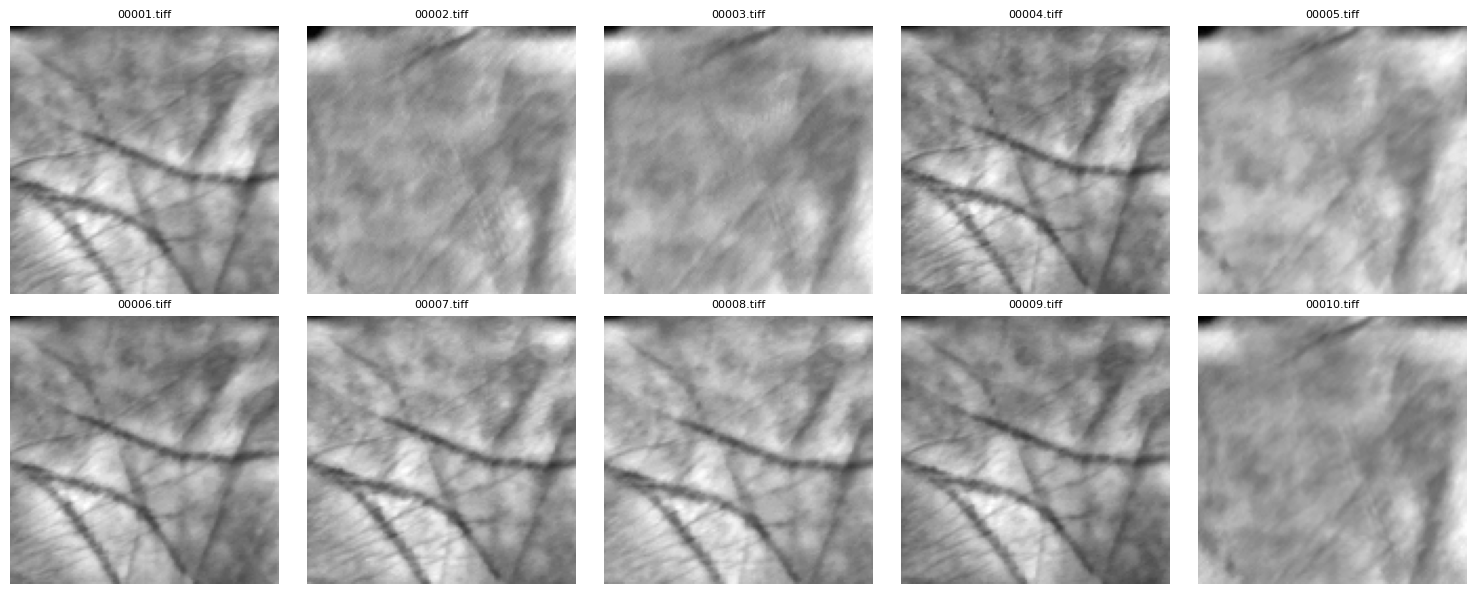

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, f in enumerate(test_files):
    path = f'/kaggle/input/palm-dataset/session1/{f}'
    result, status = preprocess_palm(path)
    ax = axes[i // 5, i % 5]
    if result is not None:
        ax.imshow(result, cmap='gray')
    ax.set_title(f, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [47]:
import os

sessions = ['session1', 'session2']
output_root = '/content/drive/MyDrive/palm_project/processed'
data_root = '/kaggle/input/palm-dataset'

os.makedirs(output_root, exist_ok=True)

failed_log = []
total = 0
success = 0

for session in sessions:
    in_dir = f'{data_root}/{session}'
    out_dir = f'{output_root}/{session}'
    os.makedirs(out_dir, exist_ok=True)

    files = sorted(os.listdir(in_dir))
    for f in files:
        total += 1
        in_path = f'{in_dir}/{f}'
        result, status = preprocess_palm(in_path)

        if result is not None:
            out_path = f'{out_dir}/{f.replace(".tiff", ".png")}'
            cv2.imwrite(out_path, result)
            success += 1
        else:
            failed_log.append((session, f, status))

        if total % 500 == 0:
            print(f"Progress: {total}/12000, success so far: {success}")

print(f"\nDone. {success}/{total} succeeded ({success/total*100:.1f}%)")
print(f"{len(failed_log)} failed")

# save the failure log so you can inspect/retry them later
import csv
with open(f'{output_root}/failed_log.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['session', 'filename', 'reason'])
    writer.writerows(failed_log)

Progress: 500/12000, success so far: 244
Progress: 1000/12000, success so far: 456
Progress: 1500/12000, success so far: 627
Progress: 2000/12000, success so far: 839
Progress: 2500/12000, success so far: 966
Progress: 3000/12000, success so far: 1149
Progress: 3500/12000, success so far: 1415
Progress: 4000/12000, success so far: 1580
Progress: 4500/12000, success so far: 1725
Progress: 5000/12000, success so far: 1930
Progress: 5500/12000, success so far: 2118
Progress: 6000/12000, success so far: 2277
Progress: 6500/12000, success so far: 2509
Progress: 7000/12000, success so far: 2729
Progress: 7500/12000, success so far: 2896
Progress: 8000/12000, success so far: 3055
Progress: 8500/12000, success so far: 3222
Progress: 9000/12000, success so far: 3444
Progress: 9500/12000, success so far: 3725
Progress: 10000/12000, success so far: 3992
Progress: 10500/12000, success so far: 4199
Progress: 11000/12000, success so far: 4421
Progress: 11500/12000, success so far: 4621
Progress: 120

In [48]:
import pandas as pd

log = pd.read_csv(f'{output_root}/failed_log.csv')
print(log['reason'].value_counts())

reason
insufficient_valleys    7200
Name: count, dtype: int64


In [49]:
def preprocess_palm(img_path, output_size=128, min_depth=60):  # lowered from 100
    ...  # rest of function unchanged

In [50]:
def preprocess_palm(img_path, output_size=128, min_depth=60):
    img = cv2.imread(img_path)
    if img is None:
        return None, "unreadable"

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None, "no_contour"
    hand_contour = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(hand_contour, returnPoints=False)
    hull = np.sort(hull, axis=0)
    defects = cv2.convexityDefects(hand_contour, hull)
    if defects is None:
        return None, "no_defects"
    defects = defects.reshape(-1, 4)

    valley_points = []
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i]
        far = tuple(hand_contour[f][0])
        depth = d / 256.0
        if depth > min_depth:
            valley_points.append((far, depth))

    if len(valley_points) < 3:
        return None, "insufficient_valleys"

    valley_points = sorted(valley_points, key=lambda x: x[0][0])
    p1 = np.array(valley_points[1][0])
    p2 = np.array(valley_points[-1][0])

    midpoint = (p1 + p2) / 2
    dist = np.linalg.norm(p2 - p1)
    angle = math.degrees(math.atan2(p2[1] - p1[1], p2[0] - p1[0]))

    h, w = img.shape[:2]
    rot_matrix = cv2.getRotationMatrix2D(tuple(midpoint), angle, 1.0)
    rotated = cv2.warpAffine(img, rot_matrix, (w, h))

    side = int(dist * 1.2)
    roi_x1 = int(midpoint[0] - side / 2)
    roi_y1 = int(midpoint[1])
    roi_x2 = roi_x1 + side
    roi_y2 = roi_y1 + side

    roi_x1, roi_y1 = max(0, roi_x1), max(0, roi_y1)
    roi_x2, roi_y2 = min(w, roi_x2), min(h, roi_y2)

    if roi_x2 - roi_x1 < 50 or roi_y2 - roi_y1 < 50:
        return None, "roi_too_small"

    roi = rotated[roi_y1:roi_y2, roi_x1:roi_x2]
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(roi_gray)
    resized = cv2.resize(enhanced, (output_size, output_size))

    return resized, "ok"

In [51]:
failed_samples = log[log['reason']=='insufficient_valleys']['filename'].head(10).tolist()
failed_session = log[log['reason']=='insufficient_valleys']['session'].head(10).tolist()

for s, f in zip(failed_session, failed_samples):
    path = f'{data_root}/{s}/{f}'
    result, status = preprocess_palm(path, min_depth=60)
    print(f, status)

00012.tiff ok
00020.tiff ok
00062.tiff ok
00083.tiff ok
00089.tiff ok
00090.tiff ok
00091.tiff insufficient_valleys
00092.tiff insufficient_valleys
00093.tiff ok
00094.tiff ok


In [52]:
failed_log = []
total = 0
success = 0

for session in sessions:
    in_dir = f'{data_root}/{session}'
    out_dir = f'{output_root}/{session}'
    os.makedirs(out_dir, exist_ok=True)

    files = sorted(os.listdir(in_dir))
    for f in files:
        total += 1
        in_path = f'{in_dir}/{f}'
        result, status = preprocess_palm(in_path, min_depth=60)

        if result is not None:
            out_path = f'{out_dir}/{f.replace(".tiff", ".png")}'
            cv2.imwrite(out_path, result)
            success += 1
        else:
            failed_log.append((session, f, status))

        if total % 500 == 0:
            print(f"Progress: {total}/12000, success so far: {success}")

print(f"\nDone. {success}/{total} succeeded ({success/total*100:.1f}%)")
print(f"{len(failed_log)} failed")

with open(f'{output_root}/failed_log.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['session', 'filename', 'reason'])
    writer.writerows(failed_log)

Progress: 500/12000, success so far: 292
Progress: 1000/12000, success so far: 565
Progress: 1500/12000, success so far: 827
Progress: 2000/12000, success so far: 1099
Progress: 2500/12000, success so far: 1269
Progress: 3000/12000, success so far: 1525
Progress: 3500/12000, success so far: 1833
Progress: 4000/12000, success so far: 2053
Progress: 4500/12000, success so far: 2286
Progress: 5000/12000, success so far: 2531
Progress: 5500/12000, success so far: 2762
Progress: 6000/12000, success so far: 2985
Progress: 6500/12000, success so far: 3282
Progress: 7000/12000, success so far: 3570
Progress: 7500/12000, success so far: 3813
Progress: 8000/12000, success so far: 4029
Progress: 8500/12000, success so far: 4258
Progress: 9000/12000, success so far: 4557
Progress: 9500/12000, success so far: 4884
Progress: 10000/12000, success so far: 5193
Progress: 10500/12000, success so far: 5463
Progress: 11000/12000, success so far: 5747
Progress: 11500/12000, success so far: 5994
Progress: 1

In [53]:
log = pd.read_csv(f'{output_root}/failed_log.csv')
print(log['reason'].value_counts())

reason
insufficient_valleys    5709
Name: count, dtype: int64


In [54]:
print(log.groupby(['session', 'reason']).size())

session   reason              
session1  insufficient_valleys    3015
session2  insufficient_valleys    2694
dtype: int64


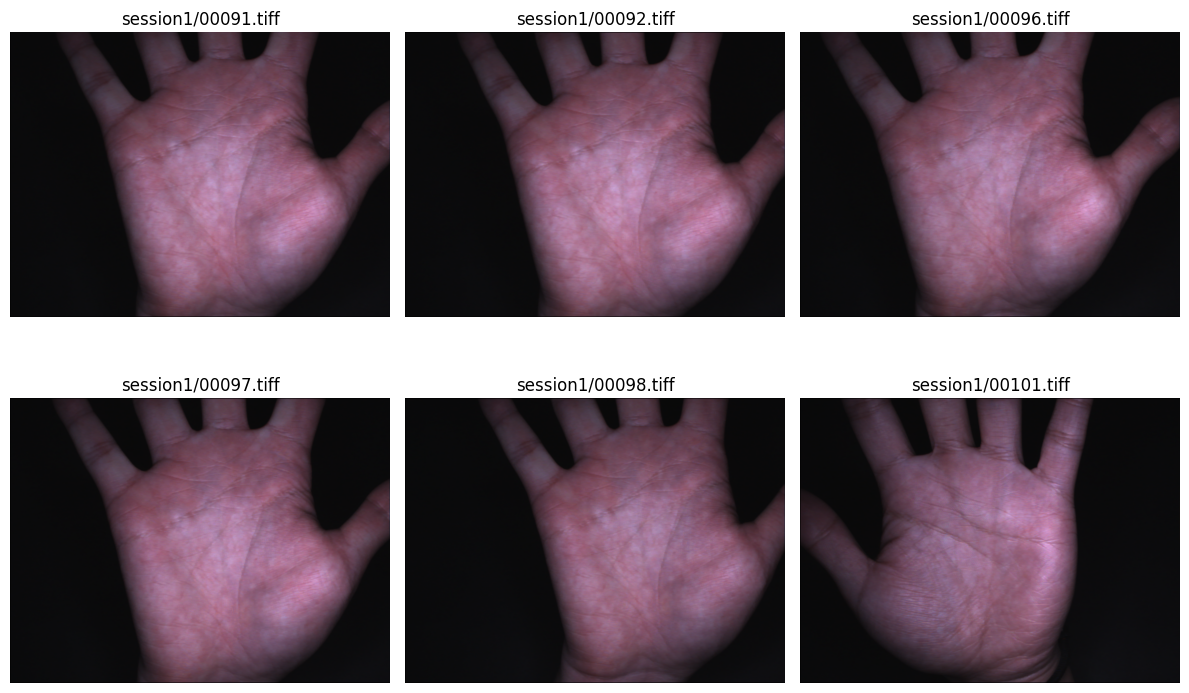

In [55]:
failed_files = log['filename'].head(6).tolist()
failed_sessions = log['session'].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, (s, f) in enumerate(zip(failed_sessions, failed_files)):
    path = f'{data_root}/{s}/{f}'
    im = cv2.imread(path)
    ax = axes[i // 3, i % 3]
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{s}/{f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

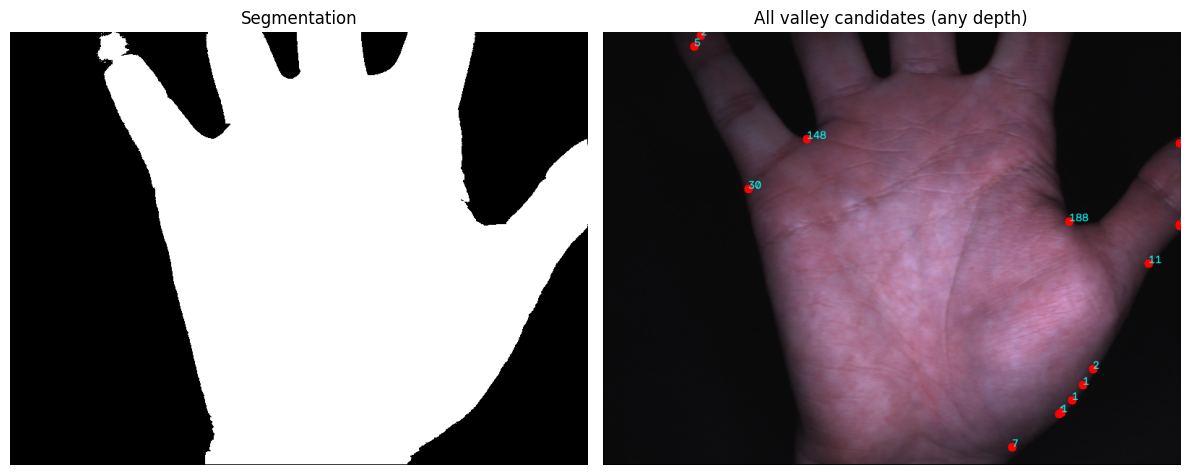

In [56]:
test_fail = f"{data_root}/{failed_sessions[0]}/{failed_files[0]}"
im = cv2.imread(test_fail)
gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
hand_contour = max(contours, key=cv2.contourArea)
hull = cv2.convexHull(hand_contour, returnPoints=False)
hull = np.sort(hull, axis=0)
defects = cv2.convexityDefects(hand_contour, hull)

vis = im.copy()
if defects is not None:
    defects = defects.reshape(-1, 4)
    for i in range(defects.shape[0]):
        s, e, f_, d = defects[i]
        far = tuple(hand_contour[f_][0])
        depth = d / 256.0
        cv2.circle(vis, far, 6, (0, 0, 255), -1)
        cv2.putText(vis, f"{depth:.0f}", far, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Segmentation')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[1].set_title('All valley candidates (any depth)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [57]:
def preprocess_palm(img_path, output_size=128, min_depth=60):
    img = cv2.imread(img_path)
    if img is None:
        return None, "unreadable"

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None, "no_contour"
    hand_contour = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(hand_contour, returnPoints=False)
    hull = np.sort(hull, axis=0)
    defects = cv2.convexityDefects(hand_contour, hull)
    if defects is None:
        return None, "no_defects"
    defects = defects.reshape(-1, 4)

    valley_points = []
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i]
        far = tuple(hand_contour[f][0])
        depth = d / 256.0
        if depth > min_depth:
            valley_points.append((far, depth))

    if len(valley_points) < 2:
        return None, "insufficient_valleys"

    valley_points = sorted(valley_points, key=lambda x: x[0][0])  # left to right by x

    if len(valley_points) >= 3:
        # 3+ valleys: skip the leftmost (likely thumb-index gap), use next and last
        p1 = np.array(valley_points[1][0])
        p2 = np.array(valley_points[-1][0])
    else:
        # exactly 2 valleys: use both directly
        p1 = np.array(valley_points[0][0])
        p2 = np.array(valley_points[-1][0])

    midpoint = (p1 + p2) / 2
    dist = np.linalg.norm(p2 - p1)
    angle = math.degrees(math.atan2(p2[1] - p1[1], p2[0] - p1[0]))

    h, w = img.shape[:2]
    rot_matrix = cv2.getRotationMatrix2D(tuple(midpoint), angle, 1.0)
    rotated = cv2.warpAffine(img, rot_matrix, (w, h))

    side = int(dist * 1.2)
    roi_x1 = int(midpoint[0] - side / 2)
    roi_y1 = int(midpoint[1])
    roi_x2 = roi_x1 + side
    roi_y2 = roi_y1 + side

    roi_x1, roi_y1 = max(0, roi_x1), max(0, roi_y1)
    roi_x2, roi_y2 = min(w, roi_x2), min(h, roi_y2)

    if roi_x2 - roi_x1 < 50 or roi_y2 - roi_y1 < 50:
        return None, "roi_too_small"

    roi = rotated[roi_y1:roi_y2, roi_x1:roi_x2]
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(roi_gray)
    resized = cv2.resize(enhanced, (output_size, output_size))

    return resized, "ok"

In [58]:
failed_samples = log[log['reason']=='insufficient_valleys']['filename'].head(20).tolist()
failed_session = log[log['reason']=='insufficient_valleys']['session'].head(20).tolist()

for s, f in zip(failed_session, failed_samples):
    path = f'{data_root}/{s}/{f}'
    result, status = preprocess_palm(path, min_depth=60)
    print(f, status)

00091.tiff ok
00092.tiff ok
00096.tiff ok
00097.tiff ok
00098.tiff ok
00101.tiff ok
00102.tiff ok
00103.tiff ok
00104.tiff ok
00105.tiff ok
00106.tiff ok
00107.tiff ok
00108.tiff ok
00109.tiff ok
00110.tiff ok
00111.tiff ok
00112.tiff ok
00113.tiff ok
00114.tiff ok
00115.tiff ok


In [59]:
failed_log = []
total = 0
success = 0

for session in sessions:
    in_dir = f'{data_root}/{session}'
    out_dir = f'{output_root}/{session}'
    os.makedirs(out_dir, exist_ok=True)

    files = sorted(os.listdir(in_dir))
    for f in files:
        total += 1
        in_path = f'{in_dir}/{f}'
        result, status = preprocess_palm(in_path, min_depth=60)

        if result is not None:
            out_path = f'{out_dir}/{f.replace(".tiff", ".png")}'
            cv2.imwrite(out_path, result)
            success += 1
        else:
            failed_log.append((session, f, status))

        if total % 500 == 0:
            print(f"Progress: {total}/12000, success so far: {success}")

print(f"\nDone. {success}/{total} succeeded ({success/total*100:.1f}%)")
print(f"{len(failed_log)} failed")

with open(f'{output_root}/failed_log.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['session', 'filename', 'reason'])
    writer.writerows(failed_log)

Progress: 500/12000, success so far: 500
Progress: 1000/12000, success so far: 1000
Progress: 1500/12000, success so far: 1500
Progress: 2000/12000, success so far: 2000
Progress: 2500/12000, success so far: 2500
Progress: 3000/12000, success so far: 2997
Progress: 3500/12000, success so far: 3497
Progress: 4000/12000, success so far: 3997
Progress: 4500/12000, success so far: 4497
Progress: 5000/12000, success so far: 4997
Progress: 5500/12000, success so far: 5494
Progress: 6000/12000, success so far: 5994
Progress: 6500/12000, success so far: 6494
Progress: 7000/12000, success so far: 6994
Progress: 7500/12000, success so far: 7494
Progress: 8000/12000, success so far: 7994
Progress: 8500/12000, success so far: 8493
Progress: 9000/12000, success so far: 8991
Progress: 9500/12000, success so far: 9491
Progress: 10000/12000, success so far: 9991
Progress: 10500/12000, success so far: 10491
Progress: 11000/12000, success so far: 10989
Progress: 11500/12000, success so far: 11488
Progre

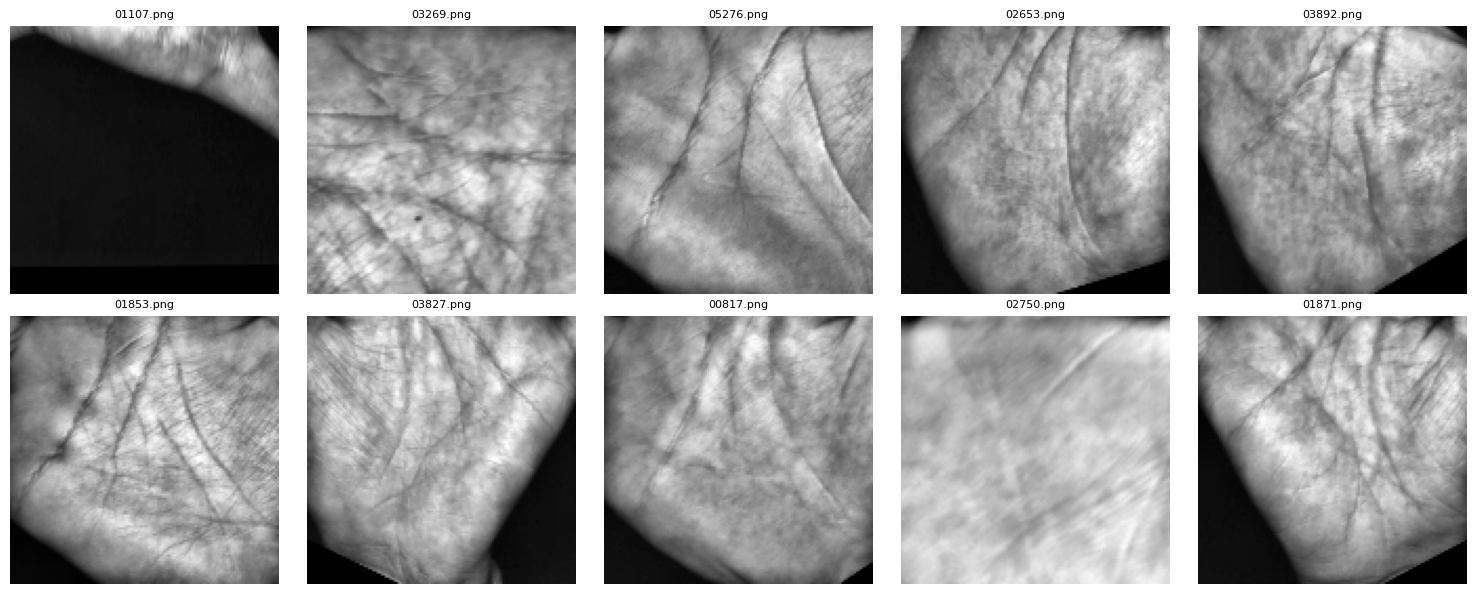

In [60]:
import random

sample_files = random.sample(os.listdir(f'{output_root}/session1'), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, f in enumerate(sample_files):
    img = cv2.imread(f'{output_root}/session1/{f}', cv2.IMREAD_GRAYSCALE)
    ax = axes[i // 5, i % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [61]:
def is_valid_roi(roi_gray, black_threshold=15, max_black_fraction=0.05):
    """Reject ROIs where too many pixels are near-black (rotation artifact)."""
    black_pixels = np.sum(roi_gray < black_threshold)
    total_pixels = roi_gray.size
    return (black_pixels / total_pixels) < max_black_fraction

In [62]:
def is_valid_roi(roi_gray, black_threshold=15, max_black_fraction=0.05):
    """Reject ROIs where too many pixels are near-black (rotation artifact)."""
    black_pixels = np.sum(roi_gray < black_threshold)
    total_pixels = roi_gray.size
    return (black_pixels / total_pixels) < max_black_fraction


def preprocess_palm(img_path, output_size=128, min_depth=60):
    img = cv2.imread(img_path)
    if img is None:
        return None, "unreadable"

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None, "no_contour"
    hand_contour = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(hand_contour, returnPoints=False)
    hull = np.sort(hull, axis=0)
    defects = cv2.convexityDefects(hand_contour, hull)
    if defects is None:
        return None, "no_defects"
    defects = defects.reshape(-1, 4)

    valley_points = []
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i]
        far = tuple(hand_contour[f][0])
        depth = d / 256.0
        if depth > min_depth:
            valley_points.append((far, depth))

    if len(valley_points) < 2:
        return None, "insufficient_valleys"

    valley_points = sorted(valley_points, key=lambda x: x[0][0])

    if len(valley_points) >= 3:
        p1 = np.array(valley_points[1][0])
        p2 = np.array(valley_points[-1][0])
    else:
        p1 = np.array(valley_points[0][0])
        p2 = np.array(valley_points[-1][0])

    midpoint = (p1 + p2) / 2
    dist = np.linalg.norm(p2 - p1)
    angle = math.degrees(math.atan2(p2[1] - p1[1], p2[0] - p1[0]))

    h, w = img.shape[:2]
    rot_matrix = cv2.getRotationMatrix2D(tuple(midpoint), angle, 1.0)
    rotated = cv2.warpAffine(img, rot_matrix, (w, h))

    side = int(dist * 1.2)
    roi_x1 = int(midpoint[0] - side / 2)
    roi_y1 = int(midpoint[1])
    roi_x2 = roi_x1 + side
    roi_y2 = roi_y1 + side

    roi_x1, roi_y1 = max(0, roi_x1), max(0, roi_y1)
    roi_x2, roi_y2 = min(w, roi_x2), min(h, roi_y2)

    if roi_x2 - roi_x1 < 50 or roi_y2 - roi_y1 < 50:
        return None, "roi_too_small"

    roi = rotated[roi_y1:roi_y2, roi_x1:roi_x2]
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    if not is_valid_roi(roi_gray):
        return None, "black_corner_artifact"

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(roi_gray)
    resized = cv2.resize(enhanced, (output_size, output_size))

    return resized, "ok"

In [63]:
failed_log = []
total = 0
success = 0

for session in sessions:
    in_dir = f'{data_root}/{session}'
    out_dir = f'{output_root}/{session}'
    os.makedirs(out_dir, exist_ok=True)

    files = sorted(os.listdir(in_dir))
    for f in files:
        total += 1
        in_path = f'{in_dir}/{f}'
        result, status = preprocess_palm(in_path, min_depth=60)

        if result is not None:
            out_path = f'{out_dir}/{f.replace(".tiff", ".png")}'
            cv2.imwrite(out_path, result)
            success += 1
        else:
            failed_log.append((session, f, status))

        if total % 500 == 0:
            print(f"Progress: {total}/12000, success so far: {success}")

print(f"\nDone. {success}/{total} succeeded ({success/total*100:.1f}%)")
print(f"{len(failed_log)} failed")

with open(f'{output_root}/failed_log.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['session', 'filename', 'reason'])
    writer.writerows(failed_log)

Progress: 500/12000, success so far: 242
Progress: 1000/12000, success so far: 432
Progress: 1500/12000, success so far: 612
Progress: 2000/12000, success so far: 820
Progress: 2500/12000, success so far: 933
Progress: 3000/12000, success so far: 1117
Progress: 3500/12000, success so far: 1352
Progress: 4000/12000, success so far: 1538
Progress: 4500/12000, success so far: 1715
Progress: 5000/12000, success so far: 1899
Progress: 5500/12000, success so far: 2068
Progress: 6000/12000, success so far: 2237
Progress: 6500/12000, success so far: 2465
Progress: 7000/12000, success so far: 2678
Progress: 7500/12000, success so far: 2825
Progress: 8000/12000, success so far: 2950
Progress: 8500/12000, success so far: 3124
Progress: 9000/12000, success so far: 3318
Progress: 9500/12000, success so far: 3551
Progress: 10000/12000, success so far: 3799
Progress: 10500/12000, success so far: 4006
Progress: 11000/12000, success so far: 4218
Progress: 11500/12000, success so far: 4371
Progress: 120

In [64]:
log = pd.read_csv(f'{output_root}/failed_log.csv')
print(log['reason'].value_counts())

reason
black_corner_artifact    7429
insufficient_valleys       12
Name: count, dtype: int64


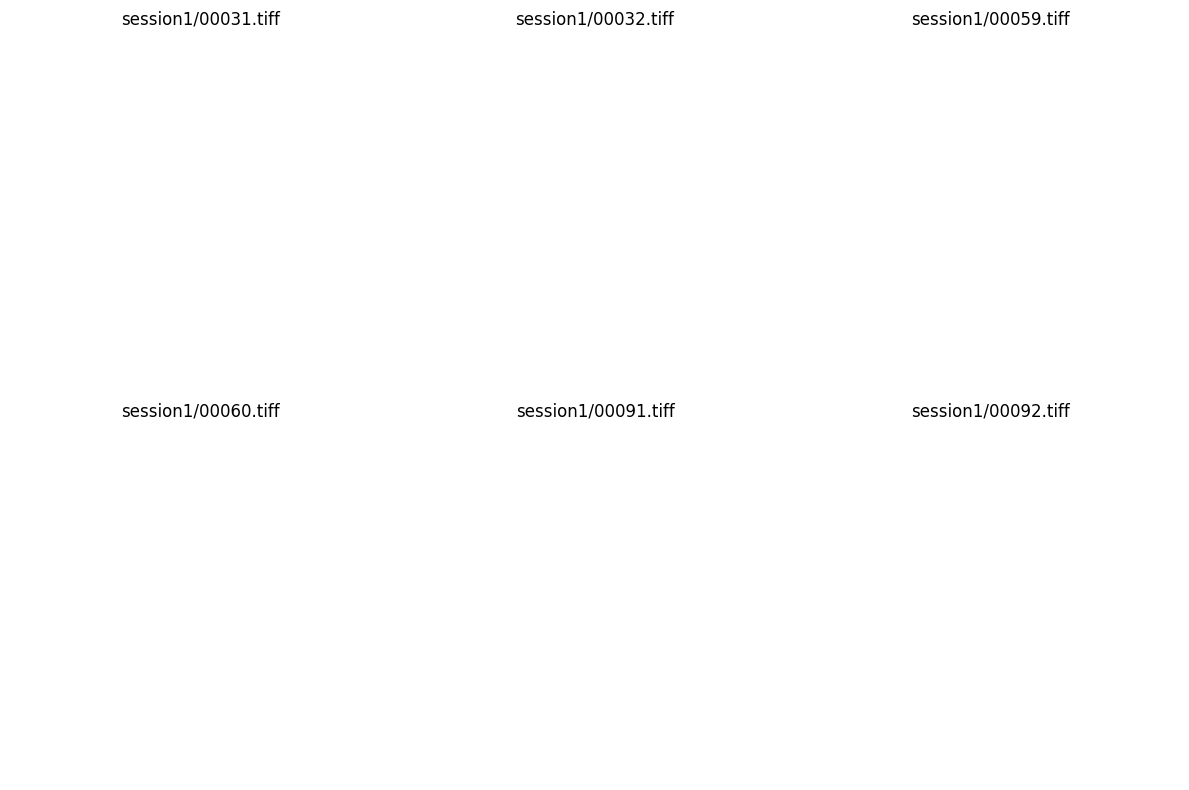

reason
black_corner_artifact    7429
insufficient_valleys       12
Name: count, dtype: int64


In [65]:
black_corner_fails = log[log['reason']=='black_corner_artifact']['filename'].head(6).tolist()
black_corner_sessions = log[log['reason']=='black_corner_artifact']['session'].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, (s, f) in enumerate(zip(black_corner_sessions, black_corner_fails)):
    path = f'{data_root}/{s}/{f}'
    result, status = preprocess_palm(path, min_depth=60)
    # show the roi even though it was rejected - temporarily bypass check for viewing
    img = cv2.imread(path)
    ax = axes[i // 3, i % 3]
    ax.set_title(f'{s}/{f}')
    ax.axis('off')
plt.tight_layout()
plt.show()
print(log['reason'].value_counts())

In [66]:
def black_fraction(roi_gray, black_threshold=15):
    return np.sum(roi_gray < black_threshold) / roi_gray.size

# check some KNOWN GOOD images (from your earlier clean grid, e.g. 00515, 00913, 01521, 01414, 01630)
good_files = ['00515.png', '00913.png', '01521.png', '01414.png', '01630.png']
print("Known good images:")
for f in good_files:
    path = f'{output_root}/session1/{f}'
    if os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        print(f, black_fraction(img))

# check the KNOWN BAD ones with visible black triangles (03521, 05173, 04123, 04065)
bad_files = ['03521.png', '05173.png', '04123.png', '04065.png']
print("\nKnown bad images (visible black corners):")
for f in bad_files:
    path = f'{output_root}/session1/{f}'
    if os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        print(f, black_fraction(img))

Known good images:
00515.png 0.064453125
00913.png 0.0865478515625
01521.png 0.000244140625
01414.png 0.12274169921875
01630.png 0.09832763671875

Known bad images (visible black corners):
03521.png 0.0
05173.png 0.10687255859375
04123.png 0.0904541015625
04065.png 0.00018310546875


In [67]:
def diagnose_black_fraction(img_path, min_depth=60, black_threshold=15):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    hand_contour = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(hand_contour, returnPoints=False)
    hull = np.sort(hull, axis=0)
    defects = cv2.convexityDefects(hand_contour, hull)
    defects = defects.reshape(-1, 4)

    valley_points = []
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i]
        far = tuple(hand_contour[f][0])
        depth = d / 256.0
        if depth > min_depth:
            valley_points.append((far, depth))

    valley_points = sorted(valley_points, key=lambda x: x[0][0])
    if len(valley_points) >= 3:
        p1 = np.array(valley_points[1][0])
        p2 = np.array(valley_points[-1][0])
    else:
        p1 = np.array(valley_points[0][0])
        p2 = np.array(valley_points[-1][0])

    midpoint = (p1 + p2) / 2
    dist = np.linalg.norm(p2 - p1)
    angle = math.degrees(math.atan2(p2[1] - p1[1], p2[0] - p1[0]))

    h, w = img.shape[:2]
    rot_matrix = cv2.getRotationMatrix2D(tuple(midpoint), angle, 1.0)
    rotated = cv2.warpAffine(img, rot_matrix, (w, h))

    side = int(dist * 1.2)
    roi_x1 = int(midpoint[0] - side / 2)
    roi_y1 = int(midpoint[1])
    roi_x2, roi_y2 = roi_x1 + side, roi_y1 + side
    roi_x1, roi_y1 = max(0, roi_x1), max(0, roi_y1)
    roi_x2, roi_y2 = min(w, roi_x2), min(h, roi_y2)

    roi = rotated[roi_y1:roi_y2, roi_x1:roi_x2]
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    frac = np.sum(roi_gray < black_threshold) / roi_gray.size
    return frac, roi_gray

# known good (raw tiff, not the PNG)
print("Known good (raw):")
for f in ['00515.tiff', '00913.tiff', '01521.tiff', '01414.tiff', '01630.tiff']:
    frac, _ = diagnose_black_fraction(f'{data_root}/session1/{f}')
    print(f, frac)

print("\nKnown bad (raw):")
for f in ['03521.tiff', '05173.tiff', '04123.tiff', '04065.tiff']:
    frac, _ = diagnose_black_fraction(f'{data_root}/session1/{f}')
    print(f, frac)

Known good (raw):
00515.tiff 0.07612182164455879
00913.tiff 0.11201623141921649
01521.tiff 0.0002571166207529844
01414.tiff 0.1572241987946376
01630.tiff 0.12184140464395242

Known bad (raw):
03521.tiff 0.0
05173.tiff 0.12976298247057855
04123.tiff 0.1744083739826879
04065.tiff 0.0002883506343713956


In [68]:
def has_black_corner(roi_gray, corner_size_frac=0.15, black_threshold=15, corner_black_fraction=0.7):
    """Check each corner patch — if ANY corner is mostly black, it's a rotation artifact."""
    h, w = roi_gray.shape
    cs = int(min(h, w) * corner_size_frac)

    corners = [
        roi_gray[0:cs, 0:cs],           # top-left
        roi_gray[0:cs, w-cs:w],         # top-right
        roi_gray[h-cs:h, 0:cs],         # bottom-left
        roi_gray[h-cs:h, w-cs:w],       # bottom-right
    ]

    for corner in corners:
        black_frac = np.sum(corner < black_threshold) / corner.size
        if black_frac > corner_black_fraction:
            return True  # found a black corner artifact
    return False

In [69]:
print("Known good — should all be False:")
for f in ['00515.tiff', '00913.tiff', '01521.tiff', '01414.tiff', '01630.tiff']:
    frac, roi_gray = diagnose_black_fraction(f'{data_root}/session1/{f}')
    print(f, has_black_corner(roi_gray))

print("\nKnown bad — should mostly be True:")
for f in ['03521.tiff', '05173.tiff', '04123.tiff', '04065.tiff']:
    frac, roi_gray = diagnose_black_fraction(f'{data_root}/session1/{f}')
    print(f, has_black_corner(roi_gray))

Known good — should all be False:
00515.tiff True
00913.tiff True
01521.tiff False
01414.tiff True
01630.tiff True

Known bad — should mostly be True:
03521.tiff False
05173.tiff True
04123.tiff True
04065.tiff False


In [70]:
rotated = cv2.warpAffine(img, rot_matrix, (w, h), borderMode=cv2.BORDER_REPLICATE)

In [71]:
def preprocess_palm(img_path, output_size=128, min_depth=60):
    img = cv2.imread(img_path)
    if img is None:
        return None, "unreadable"

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None, "no_contour"
    hand_contour = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(hand_contour, returnPoints=False)
    hull = np.sort(hull, axis=0)
    defects = cv2.convexityDefects(hand_contour, hull)
    if defects is None:
        return None, "no_defects"
    defects = defects.reshape(-1, 4)

    valley_points = []
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i]
        far = tuple(hand_contour[f][0])
        depth = d / 256.0
        if depth > min_depth:
            valley_points.append((far, depth))

    if len(valley_points) < 2:
        return None, "insufficient_valleys"

    valley_points = sorted(valley_points, key=lambda x: x[0][0])

    if len(valley_points) >= 3:
        p1 = np.array(valley_points[1][0])
        p2 = np.array(valley_points[-1][0])
    else:
        p1 = np.array(valley_points[0][0])
        p2 = np.array(valley_points[-1][0])

    midpoint = (p1 + p2) / 2
    dist = np.linalg.norm(p2 - p1)
    angle = math.degrees(math.atan2(p2[1] - p1[1], p2[0] - p1[0]))

    h, w = img.shape[:2]
    rot_matrix = cv2.getRotationMatrix2D(tuple(midpoint), angle, 1.0)
    rotated = cv2.warpAffine(img, rot_matrix, (w, h), borderMode=cv2.BORDER_REPLICATE)  # <-- the fix

    side = int(dist * 1.2)
    roi_x1 = int(midpoint[0] - side / 2)
    roi_y1 = int(midpoint[1])
    roi_x2 = roi_x1 + side
    roi_y2 = roi_y1 + side

    roi_x1, roi_y1 = max(0, roi_x1), max(0, roi_y1)
    roi_x2, roi_y2 = min(w, roi_x2), min(h, roi_y2)

    if roi_x2 - roi_x1 < 50 or roi_y2 - roi_y1 < 50:
        return None, "roi_too_small"

    roi = rotated[roi_y1:roi_y2, roi_x1:roi_x2]
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(roi_gray)
    resized = cv2.resize(enhanced, (output_size, output_size))

    return resized, "ok"

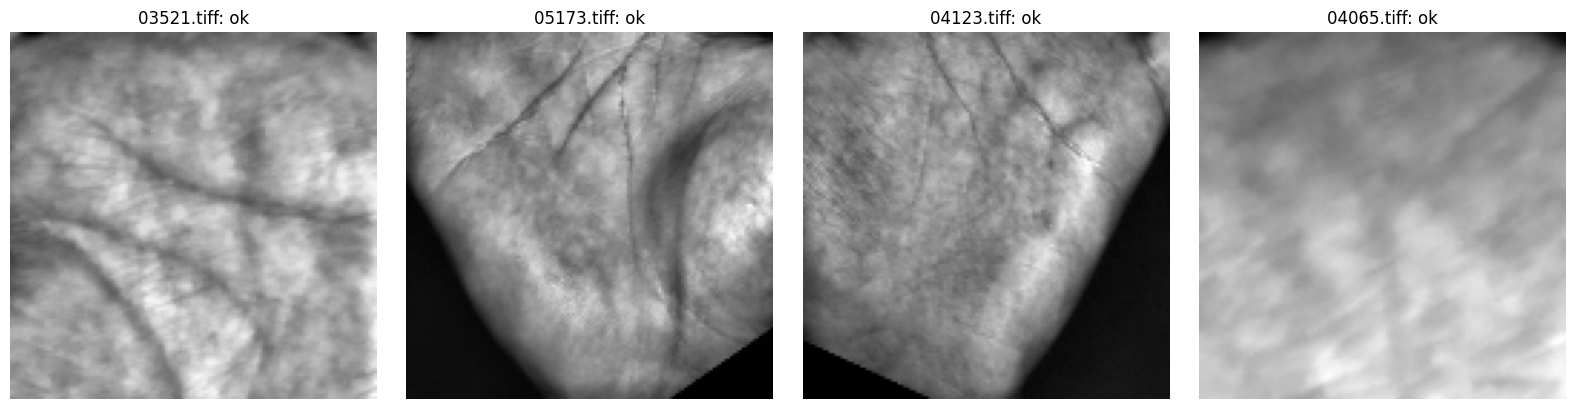

In [72]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, f in enumerate(['03521.tiff', '05173.tiff', '04123.tiff', '04065.tiff']):
    result, status = preprocess_palm(f'{data_root}/session1/{f}')
    ax = axes[i]
    if result is not None:
        ax.imshow(result, cmap='gray')
    ax.set_title(f'{f}: {status}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [73]:
failed_log = []
total = 0
success = 0

for session in sessions:
    in_dir = f'{data_root}/{session}'
    out_dir = f'{output_root}/{session}'
    os.makedirs(out_dir, exist_ok=True)

    files = sorted(os.listdir(in_dir))
    for f in files:
        total += 1
        in_path = f'{in_dir}/{f}'
        result, status = preprocess_palm(in_path, min_depth=60)

        if result is not None:
            out_path = f'{out_dir}/{f.replace(".tiff", ".png")}'
            cv2.imwrite(out_path, result)
            success += 1
        else:
            failed_log.append((session, f, status))

        if total % 500 == 0:
            print(f"Progress: {total}/12000, success so far: {success}")

print(f"\nDone. {success}/{total} succeeded ({success/total*100:.1f}%)")
print(f"{len(failed_log)} failed")

with open(f'{output_root}/failed_log.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['session', 'filename', 'reason'])
    writer.writerows(failed_log)

Progress: 500/12000, success so far: 500
Progress: 1000/12000, success so far: 1000
Progress: 1500/12000, success so far: 1500
Progress: 2000/12000, success so far: 2000
Progress: 2500/12000, success so far: 2500
Progress: 3000/12000, success so far: 2997
Progress: 3500/12000, success so far: 3497
Progress: 4000/12000, success so far: 3997
Progress: 4500/12000, success so far: 4497
Progress: 5000/12000, success so far: 4997
Progress: 5500/12000, success so far: 5494
Progress: 6000/12000, success so far: 5994
Progress: 6500/12000, success so far: 6494
Progress: 7000/12000, success so far: 6994
Progress: 7500/12000, success so far: 7494
Progress: 8000/12000, success so far: 7994
Progress: 8500/12000, success so far: 8493
Progress: 9000/12000, success so far: 8991
Progress: 9500/12000, success so far: 9491
Progress: 10000/12000, success so far: 9991
Progress: 10500/12000, success so far: 10491
Progress: 11000/12000, success so far: 10989
Progress: 11500/12000, success so far: 11488
Progre

In [74]:
local_output = '/content/processed'

In [75]:
print(output_root)
!ls {output_root}/session1 | head -20

/content/drive/MyDrive/palm_project/processed
00001.png
00002.png
00003.png
00004.png
00005.png
00006.png
00007.png
00008.png
00009.png
00010.png
00011.png
00012.png
00013.png
00014.png
00015.png
00016.png
00017.png
00018.png
00019.png
00020.png


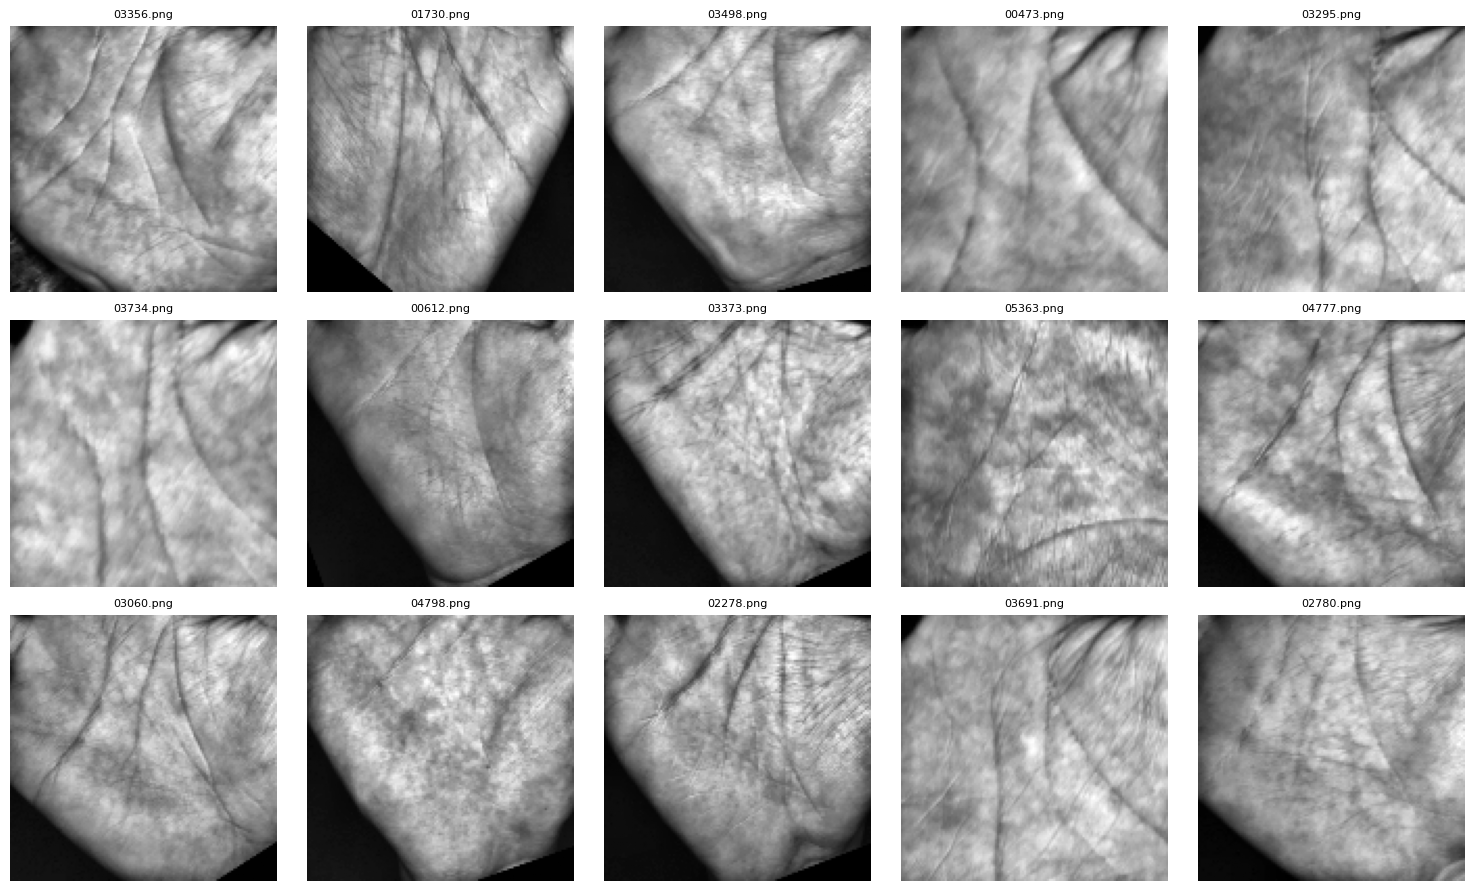

In [76]:
import random

sample_files = random.sample(os.listdir(f'{output_root}/session1'), 15)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, f in enumerate(sample_files):
    img = cv2.imread(f'{output_root}/session1/{f}', cv2.IMREAD_GRAYSCALE)
    ax = axes[i // 5, i % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

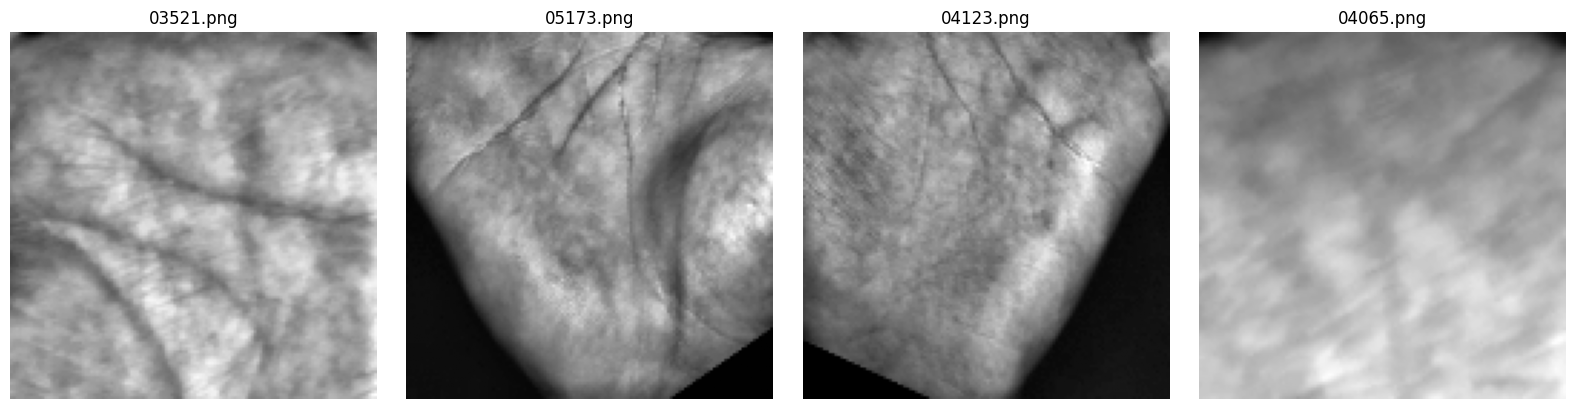

In [77]:
check_files = ['03521.png', '05173.png', '04123.png', '04065.png']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, f in enumerate(check_files):
    path = f'{output_root}/session1/{f}'
    if os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f)
        axes[i].axis('off')
plt.tight_layout()
plt.show()

In [78]:
def has_black_triangle(img_path, corner_frac=0.15, black_thresh=15, black_ratio_thresh=0.6):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    cs = int(min(h, w) * corner_frac)
    corners = [img[0:cs,0:cs], img[0:cs,w-cs:w], img[h-cs:h,0:cs], img[h-cs:h,w-cs:w]]
    return any(np.sum(c < black_thresh)/c.size > black_ratio_thresh for c in corners)

check_files = ['03521.png', '05173.png', '04123.png', '04065.png']
for f in check_files:
    path = f'{output_root}/session1/{f}'
    if os.path.exists(path):
        print(f, "still has black corner:", has_black_triangle(path))

03521.png still has black corner: False
05173.png still has black corner: True
04123.png still has black corner: True
04065.png still has black corner: False


In [79]:
import random

sample = random.sample(os.listdir(f'{output_root}/session1'), 200)
flagged = sum(has_black_triangle(f'{output_root}/session1/{f}') for f in sample)
print(f"{flagged}/200 flagged with possible black corner")

121/200 flagged with possible black corner
